### Stochastic interpolant with **equivariant OT**: COM-free Gaussian → LJ13 cluster

The LJ13 analogue of `XY_chain_eqOT.ipynb`. Instead of training from scratch, we warm-start
the drift from the released **`LJ13_eq_OT_flow_matching`** checkpoint (Klein, Kraemer & Noé
2023; OSF [srqg7](https://osf.io/srqg7/)) and learn a score field alongside it, turning a
plain flow into a proper stochastic interpolant.

- `load_ref_data`  — the target dataset `p₁`: OSF MCMC samples of the 13-atom LJ cluster.
- `sample_prior`   — the base `p₀`: COM-free unit Gaussian on the 36-dim mean-zero subspace.
- `make_si_model`  — an `LJ13EESI` wrapping two `LJ13Dynamics` E(n)-GNNs (drift + score).
- `si_step` / `train_si` — one coupled step / the full loop. The coupling
  (`eesi.ot.equivariant_ot_couple`) runs under `no_grad` and just re-pairs the batch before
  `model.loss`, so nothing about the interpolant changes.

The coupling has two independent layers, toggled per call: `align` (OT over the symmetry
group S(13) × SO(3)) and `batch` (minibatch OT over the batch). For LJ13 the group is large
and `align` dominates — the opposite of the XY chain, where the group is tiny. See
`eesi/ot.py`.

**Conventions** (resolved in `eesi/models/lj13_dynamics.py`, do not re-derive): t=0 → prior,
t=1 → target; states are `(B, 13, 3)` and mean-free throughout; everything is float64.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.datasets.lj13 import load_ref_data, sample_prior, lj_energy
from eesi.models.lj13_dynamics import LJ13Dynamics, rk4_sample
from eesi.ot import equivariant_ot_couple, transport_cost
from eesi.train.lj13 import make_si_model, si_step, train_si

%matplotlib inline
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [3]:
_IU = torch.triu_indices(13, 13, offset=1)          # the 78 unique pairs

def pair_distances(x):                              # (B,13,3) -> (B*78,) all pair distances
    iu = _IU.to(x.device)
    d = x[:, iu[0]] - x[:, iu[1]]
    return d.pow(2).sum(-1).sqrt().reshape(-1).cpu().numpy()

def energy(x):                                      # physical (i<j) LJ energy, min = -44.327
    return lj_energy(x, ordered=False).cpu().numpy()

def smooth(v, k=25):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

# Apply a sampler to x0 in chunks. The ODE/SDE have no batch coupling, so this is
# exactly equivalent to one big call -- it only caps peak GPU memory (13 atoms x
# 156 directed edges per config adds up fast at B=5000).
@torch.no_grad()
def chunked(fn, x0, size=1000):
    return torch.cat([fn(c) for c in x0.split(size)])

### 1. Datasets & samplers

`load_ref_data` slices the memory-mapped 10M × 39 OSF array *before* materializing it, so we
never pull the full 1.5 GB into RAM. The shipped configurations are already COM-free;
re-centering only removes float drift. `sample_prior` is the base `p₀`, drawn fresh each
step. Both distributions are S(13) × SO(3)-invariant, which is what makes the
equivariant-OT coupling marginal-preserving.

In [5]:
n_data = 100_000
x1_all = load_ref_data(n=n_data).to(device)
print("target dataset:", tuple(x1_all.shape))

x0_demo = sample_prior(4, device=device)
print("base sample   :", tuple(x0_demo.shape))

# Both marginals must live on the mean-zero subspace; the whole interpolant depends on it.
print(f"max |COM| data : {x1_all.mean(1).abs().max().item():.2e}")
print(f"max |COM| prior: {x0_demo.mean(1).abs().max().item():.2e}")

e_ref = energy(x1_all[:20_000])
print(f"reference energy: <E> = {e_ref.mean():+.3f}   min = {e_ref.min():+.3f} "
      f"(global minimum is -44.327)")

target dataset: (100000, 13, 3)
base sample   : (4, 13, 3)
max |COM| data : 1.02e-16
max |COM| prior: 6.83e-17
reference energy: <E> = -26.108   min = -35.318 (global minimum is -44.327)


#### 1.1. What the coupling buys

The 2×2 of `align` (OT over the group) and `batch` (OT over the minibatch). The reported
number is the mean squared transport cost `‖x₀ − x₁‖²` of the resulting pairing — lower is a
straighter, easier-to-learn path. Unlike the XY chain, LJ13 has a large symmetry group, so
`align` should carry most of the reduction.

In [17]:
torch.manual_seed(0)
batch_size = 256   # held FIXED across training, sampling, and entropy -- see the note below

_x1 = x1_all[torch.randint(0, n_data, (batch_size,), device=device)]
_x0 = sample_prior(batch_size, device=device)

base = None
for align, batch in [(False, False), (False, True), (True, False), (True, True)]:
    a, b = equivariant_ot_couple(_x0, _x1, align=align, batch=batch)
    c = transport_cost(a, b).item()
    base = c if base is None else base
    label = f"align={str(align):5s} batch={str(batch):5s}"
    print(f"{label}  transport {c:8.2f}   ({100 * (c / base - 1):+6.1f}% vs random)")

align=False batch=False  transport    53.90   (  +0.0% vs random)
align=False batch=True   transport    32.62   ( -39.5% vs random)
align=True  batch=False  transport    13.79   ( -74.4% vs random)
align=True  batch=True   transport     9.19   ( -83.0% vs random)


> **Batch size is load-bearing.** The minibatch-OT layer makes the coupling — and therefore
> the time-dependent marginals the model is fit to — depend on the batch size. Keep
> `batch_size` identical in training and in any downstream estimate that re-couples
> (§5). Sampling in §4 involves no coupling, so chunking there is free.

### 2. Model & checkpoint load

`make_si_model` returns an `LJ13EESI` wrapping two independent `LJ13Dynamics` E(n)-GNNs, one
for the drift `b` and one for the score `s`. We use the **linear** path, matching the
convention the released checkpoint was trained under, with a `sqrt` latent-noise schedule so
the score trains against the cheap antithetic denoising objective rather than implicit score
matching.

The checkpoint is a *flow-matching velocity*, i.e. exactly `b(t,x) = E[x₁ − x₀ | x_t]` for
the **noiseless** linear interpolant. Switching on the latent noise (`gamma_scale > 0`)
smears the marginals slightly, so the checkpoint is a close **warm start** for `net_b`, not
the exact optimum — it lands the drift in the right basin and training refines it from
there. `net_s` starts from scratch.

In [18]:
model = make_si_model(
    n_particles=13, n_dims=3,
    path="linear", gamma="sqrt", gamma_scale=0.25,
    score_div_method="exact",
).to(device=device, dtype=torch.float64)

print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

# Warm-start the drift from the released OSF equivariant-OT flow-matching checkpoint.
ckpt = LJ13Dynamics.from_checkpoint().to(device=device, dtype=torch.float64)
model.net_b.load_state_dict(ckpt.state_dict())
print("loaded checkpoint into net_b")

net_b params: 22468
net_s params: 22468
loaded checkpoint into net_b


#### 2.1. Baseline: the checkpoint on its own

Push the prior through the raw checkpoint with the RK4 integrator it was validated with.
This is the bar the trained interpolant has to hold onto — a warm start that gets *worse*
after training means the learning rate knocked the drift out of its basin.

In [19]:
torch.manual_seed(1)
x0_base = sample_prior(2_000, device=device)
gen_ckpt = chunked(lambda c: rk4_sample(ckpt, c, n_steps=100), x0_base)
e_ckpt = energy(gen_ckpt)
print(f"checkpoint (RK4): <E> = {e_ckpt.mean():+.3f}   std = {e_ckpt.std():.3f}")
print(f"reference       : <E> = {e_ref.mean():+.3f}   std = {e_ref.std():.3f}")

checkpoint (RK4): <E> = -25.329   std = 2.987
reference       : <E> = -26.108   std = 2.936


### 3. Training with equivariant OT

`train_si` runs the coupled loop: draw a target minibatch, draw a fresh COM-free base batch,
apply `equivariant_ot_couple`, and minimise `loss_b + loss_s`. Both nets are optimised
jointly by a single Adam at a deliberately **low** learning rate (`1e-4`): `net_b` is already
near-optimal and only needs refining toward the noisy-interpolant drift, so a large step
would undo the warm start. The logged `transport` cost is the coupling diagnostic from §1.1.

Setting `align`, `batch_ot` both `True` is the full S(13) × SO(3) equivariant-OT coupling;
flip either off for the ablation arms.

In [20]:
model, hist = train_si(
    x1_all, model=model,
    steps=2_000, batch=batch_size, lr=1e-4,
    align=True, batch_ot=True,     # full equivariant-OT coupling
    device=str(device), seed=0, log_every=50,
)
hist_b, hist_s = map(np.asarray, zip(*hist))

  step     0  loss_b   -0.3759  loss_s  -18.2682  transport    9.19  (  0.3s)
  step    50  loss_b   -1.1499  loss_s  -23.7393  transport    8.90  (  7.0s)
  step   100  loss_b   -1.9907  loss_s  -30.8849  transport    9.64  ( 13.7s)
  step   150  loss_b   -2.1340  loss_s  -40.8317  transport    9.47  ( 20.5s)
  step   200  loss_b   -2.1996  loss_s  -54.1076  transport    9.06  ( 27.2s)
  step   250  loss_b   -2.2848  loss_s  -67.6920  transport    9.26  ( 33.9s)
  step   300  loss_b   -2.2748  loss_s  -77.0106  transport    9.36  ( 40.6s)
  step   350  loss_b   -2.2811  loss_s  -80.7876  transport    9.23  ( 47.3s)
  step   400  loss_b   -2.3227  loss_s  -84.4383  transport    9.10  ( 54.0s)
  step   450  loss_b   -2.3380  loss_s  -89.2705  transport    9.27  ( 60.8s)
  step   500  loss_b   -2.3311  loss_s  -89.1952  transport    9.08  ( 67.5s)
  step   550  loss_b   -2.3548  loss_s  -90.9944  transport    9.04  ( 74.2s)
  step   600  loss_b   -2.3321  loss_s  -94.0205  transport    9

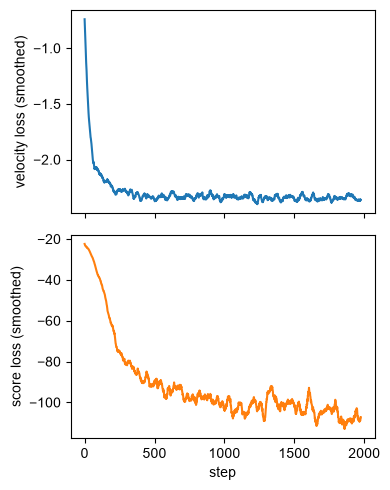

In [21]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the built-in samplers (inherited unchanged from `EESI`):
`sample_ode` integrates the probability-flow ODE `dx/dt = b(t, x)`; `sample_sde` integrates
the reverse-time SDE using both `b` and `s`. There is no closed form to compare against
here, so we validate on two physical observables of generated vs. reference configurations:
the pair-distance distribution *g(r)*, and the Lennard-Jones energy.

In [22]:
torch.manual_seed(4)
n_gen = 1_000
x0 = sample_prior(n_gen, device=device)
gen_ode = chunked(lambda c: model.sample_ode(c, n_steps=100), x0)
gen_sde = chunked(lambda c: model.sample_sde(c, n_steps=200, eps=0.25), x0)
print("COM drift (SDE):", gen_sde.mean(1).abs().max().item())   # the SDE noise stays COM-free

COM drift (SDE): 9.906605450501397e-16


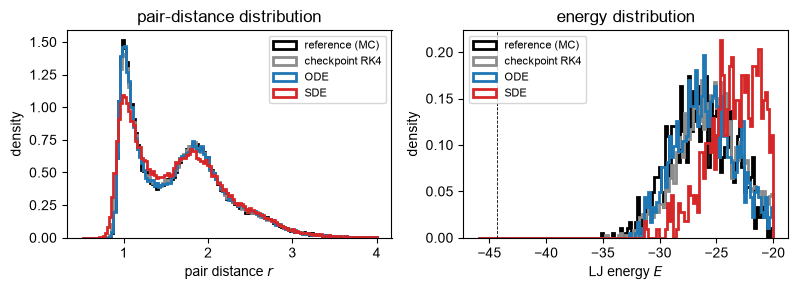

reference (MC)    <E> =  -26.158   std(E) =  2.909   min =  -35.096
checkpoint RK4    <E> =  -25.329   std(E) =  2.987   min =  -34.624
ODE               <E> =  -25.851   std(E) =  2.789   min =  -32.566
SDE               <E> =  -19.797   std(E) =  6.593   min =  -31.233


In [23]:
series = [(x1_all[:n_gen], "reference (MC)", "k"),
          (gen_ckpt,       "checkpoint RK4", "0.55"),
          (gen_ode,        "ODE",            "C0"),
          (gen_sde,        "SDE",            "C3")]

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
rbins = np.linspace(0.5, 4.0, 140)
for x, lbl, c in series:
    ax[0].hist(pair_distances(x), bins=rbins, density=True, histtype="step", lw=2,
               label=lbl, color=c)
ax[0].set_xlabel(r"pair distance $r$"); ax[0].set_ylabel("density")
ax[0].set_title("pair-distance distribution"); ax[0].legend(fontsize=8)

ebins = np.linspace(-46, -20, 140)
for x, lbl, c in series:
    ax[1].hist(energy(x), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].axvline(-44.327, c="k", lw=0.6, ls="--")
ax[1].set_xlabel("LJ energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for x, lbl, _ in series:
    e = energy(x)
    print(f"{lbl:16s}  <E> = {e.mean():+8.3f}   std(E) = {e.std():6.3f}   min = {e.min():+8.3f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways (all inherited
from `EESI`): `entropy_estimate_dot` (mean of $-b\cdot s$), `entropy_estimate_div` (mean of
$\nabla\!\cdot b$, score-free — Hutchinson with **centered** probes, so the trace is taken on
the 36-dim COM-free subspace, not the 39-dim ambient space), and the running ODE path
integral from `sample_ode_entropy_traj`.

Unlike the XY chain there is no closed form to check against, so the test is *mutual*
agreement of the three estimators. They fail in different ways — `dot` compounds score error
onto drift error, `div` is score-free but higher-variance — so agreement is real evidence.
The batched estimators re-couple, hence `batch_size` again.

In [24]:
model.score_div_method = "exact"
torch.manual_seed(2)
n_batches = 50
means_dot, means_div = [], []
for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1 = x1_all[idx]
    x0 = sample_prior(batch_size, device=device)
    x0, x1 = equivariant_ot_couple(x0, x1)
    means_dot.append(model.entropy_estimate_dot(x1, x0).mean().item())
    means_div.append(model.entropy_estimate_div(x1, x0).mean().detach().item())

print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.3f} ± {np.std(means_dot):.3f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.3f} ± {np.std(means_div):.3f}")

entropy estimate (b·s)   : -21.531 ± 0.719
entropy estimate (div b) : -33.843 ± 2.294


entropy estimate (ODE path integral): -21.228


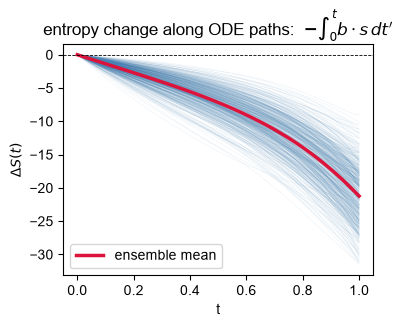

In [25]:
# Running entropy change along many ODE paths.
torch.manual_seed(3)
x0 = sample_prior(1_000, device=device)
traj, ent_traj, ts = model.sample_ode_entropy_traj(x0, n_steps=100)
ts_c, ent_c = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (ODE path integral): {ent_c[-1].mean():+.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c.mean(axis=1), c="crimson", lw=2.5, label="ensemble mean")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.set_title(r"entropy change along ODE paths:  $-\int_0^t b\cdot s\,dt'$")
ax.legend()
plt.show()

For orientation: the free-energy change for this checkpoint was previously established as
$\Delta F = F_{\rm target} - F_{\rm prior} \approx -26.83$ nats (exact subspace log-det, see
`lj13_sampling.ipynb`). With $\Delta F = \Delta U - T\Delta S$ at $T=1$, the entropy estimates
above and the mean $\Delta U$ below should be mutually consistent — a cross-check on the
*trained* interpolant against a number derived independently from the untrained checkpoint.

In [26]:
from eesi.datasets.lj13 import delta_energy

dU = delta_energy(gen_ode).mean().item()
dS = np.mean(means_div)
print(f"<dU>       = {dU:+.3f}")
print(f"dS (div b) = {dS:+.3f}")
print(f"dF = dU - dS = {dU - dS:+.3f}   (reference: -26.83 from the flow log-det)")

<dU>       = -51.701
dS (div b) = -33.843
dF = dU - dS = -17.858   (reference: -26.83 from the flow log-det)


#### Save the models

In [ ]:
torch.save(model.net_b.state_dict(), "lj13_b_si_B256.pth")
torch.save(model.net_s.state_dict(), "lj13_s_si_B256.pth")
print("saved lj13_{b,s}_si_B256.pth")